# Placement Simulation
## Project: Product Placement Optimisation
### Purpose: Translate MBA findings into shelf placement recommendations
### and calculate projected revenue impact for the case study store
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

## Why Placement Simulation?

We cannot physically rearrange the store and wait months to measure results.
Instead we use our MBA association rules to:
1. Design an optimized shelf layout based on buying patterns
2. Calculate the projected increase in average basket value
3. Estimate additional annual revenue for the store

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import os
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

print("Data loaded!")
print(f"Rows: {len(df):,}")
print(f"Categories: {df['category'].nunique()}")

Data loaded!
Rows: 767,180
Categories: 25


## Step 1: Current Store Baseline Metrics

In [2]:
basket_values = df.groupby('invoice_no')['total_amount'].sum()
total_revenue = df['total_amount'].sum()
total_baskets = df['invoice_no'].nunique()
avg_basket = basket_values.mean()
daily_revenue = total_revenue / 307
daily_customers = total_baskets / 307

print("CURRENT STORE BASELINE")
print("=" * 50)
print(f"Total Revenue (10 months):  Rs {total_revenue:>15,.2f}")
print(f"Total Shopping Trips:       {total_baskets:>15,}")
print(f"Average Basket Value:       Rs {avg_basket:>15,.2f}")
print(f"Daily Average Revenue:      Rs {daily_revenue:>15,.2f}")
print(f"Daily Customer Trips:       {daily_customers:>15,.0f}")
print(f"Data Period:                307 days")
print(f"\nPRIMARY KPI BASELINE: Rs {avg_basket:.2f} per basket")

CURRENT STORE BASELINE
Total Revenue (10 months):  Rs  218,214,456.88
Total Shopping Trips:               218,037
Average Basket Value:       Rs        1,000.81
Daily Average Revenue:      Rs      710,796.28
Daily Customer Trips:                   710
Data Period:                307 days

PRIMARY KPI BASELINE: Rs 1000.81 per basket


### How we went from 3 clusters to 5 zones

Notebook 06 clustering gave us 3 natural groups:
- Cluster 1: Daily essentials bought together regularly
- Cluster 2: Occasional and speciality items
- Cluster 3: Core staples, FOOD STAPLES and CANNED AND PACKAGED FOODS

We expanded these 3 clusters into 5 zones by using the MBA association rules from notebook 05 to split the daily essentials cluster into more specific areas. Zone 1 is the core high lift rule categories. Zone 2 is impulse buy items near the entrance. Zone 3 is personal and household care. Zone 4 is cold and fresh items needing refrigeration. Zone 5 is the perimeter for destination categories like rice, alcohol and cigarettes.

## Step 2: Define Placement Zones Based on MBA Rules

In [3]:
placement_zones = {
    'Zone 1: Daily Essentials Core': {
        'categories': [
            'FOOD STAPLES',
            'COOKING OIL', 
            'CLEANING SUPPLIES',
            'TEA AND SPICES',
            'HOUSEHOLD ITEMS'
        ],
        'color': '#FF6B6B',
        'rationale': 'Strongest MBA rules (lift 5.5-6.8). These 5 categories appear together constantly.',
        'location': 'Center of store - highest traffic area'
    },
    'Zone 2: Snacks and Drinks': {
        'categories': [
            'NOODLES',
            'SOFT DRINKS AND JUICES',
            'BISCUITS AND COOKIES',
            'CONFECTIONERY',
            'NAMKEEN AND SNACKS',
            'CANNED AND PACKAGED FOODS'
        ],
        'color': '#4ECDC4',
        'rationale': 'Frequently bought together, impulse purchase zone.',
        'location': 'Near entrance - encourages impulse buying'
    },
    'Zone 3: Personal and Baby Care': {
        'categories': [
            'PERSONAL CARE',
            'BABY CARE',
            'STATIONERY'
        ],
        'color': '#45B7D1',
        'rationale': 'Planned purchases, customers seek these out.',
        'location': 'Side aisle - customers will find them'
    },
    'Zone 4: Dairy and Fresh': {
        'categories': [
            'DAIRY PRODUCTS',
            'FROZEN FOODS',
            'FRUITS AND VEGETABLES',
            'BAKERY'
        ],
        'color': '#96CEB4',
        'rationale': 'Fresh and cold items grouped together.',
        'location': 'Back of store - draws customers through'
    },
    'Zone 5: Special Categories': {
        'categories': [
            'RICE',
            'ALCOHOLIC BEVERAGES',
            'CIGARETTE AND TOBACCO',
            'POOJA ITEMS',
            'BREAKFAST CEREALS',
            'ELECTRICAL SUPPLIES',
            'PARTY SUPPLIES'
        ],
        'color': '#FFEAA7',
        'rationale': 'Destination purchases, less frequent.',
        'location': 'Dedicated sections around store perimeter'
    }
}

print("PLACEMENT ZONES DEFINED")
print("=" * 60)
for zone, details in placement_zones.items():
    print(f"\n{zone}")
    print(f"  Location:   {details['location']}")
    print(f"  Rationale:  {details['rationale']}")
    print(f"  Categories: {', '.join(details['categories'])}")

PLACEMENT ZONES DEFINED

Zone 1: Daily Essentials Core
  Location:   Center of store - highest traffic area
  Rationale:  Strongest MBA rules (lift 5.5-6.8). These 5 categories appear together constantly.
  Categories: FOOD STAPLES, COOKING OIL, CLEANING SUPPLIES, TEA AND SPICES, HOUSEHOLD ITEMS

Zone 2: Snacks and Drinks
  Location:   Near entrance - encourages impulse buying
  Rationale:  Frequently bought together, impulse purchase zone.
  Categories: NOODLES, SOFT DRINKS AND JUICES, BISCUITS AND COOKIES, CONFECTIONERY, NAMKEEN AND SNACKS, CANNED AND PACKAGED FOODS

Zone 3: Personal and Baby Care
  Location:   Side aisle - customers will find them
  Rationale:  Planned purchases, customers seek these out.
  Categories: PERSONAL CARE, BABY CARE, STATIONERY

Zone 4: Dairy and Fresh
  Location:   Back of store - draws customers through
  Rationale:  Fresh and cold items grouped together.
  Categories: DAIRY PRODUCTS, FROZEN FOODS, FRUITS AND VEGETABLES, BAKERY

Zone 5: Special Categori

### Important Note: Data Driven vs Physical Constraints

The placement zones below are designed purely from data patterns. Before implementing them in the actual store, the following physical constraints must also be considered:

1. **Refrigeration requirement** - DAIRY PRODUCTS and FROZEN FOODS must stay near the cold storage unit regardless of what the data suggests. Moving them away from refrigeration is not possible.

2. **Customer entry point** - Zone 2 is designed as the entrance zone. This assumes customers enter from the front. If the store has a side entrance or multiple entry points, Zone 2 placement should be adjusted accordingly.

3. **Aisle width** - High traffic categories like FOOD STAPLES and CLEANING SUPPLIES placed in Zone 1 center will attract more customers to that area. The center aisle must be wide enough to handle increased foot traffic.

4. **Existing infrastructure** - Heavy items like RICE are placed in Zone 5 perimeter partly because moving them requires significant shelf restructuring. The data supports this placement as well since rice is a destination purchase.

The data tells us what customers buy together. Common sense and store layout tell us what is physically possible. The best placement strategy uses both.

## Step 3: Visual Store Planogram

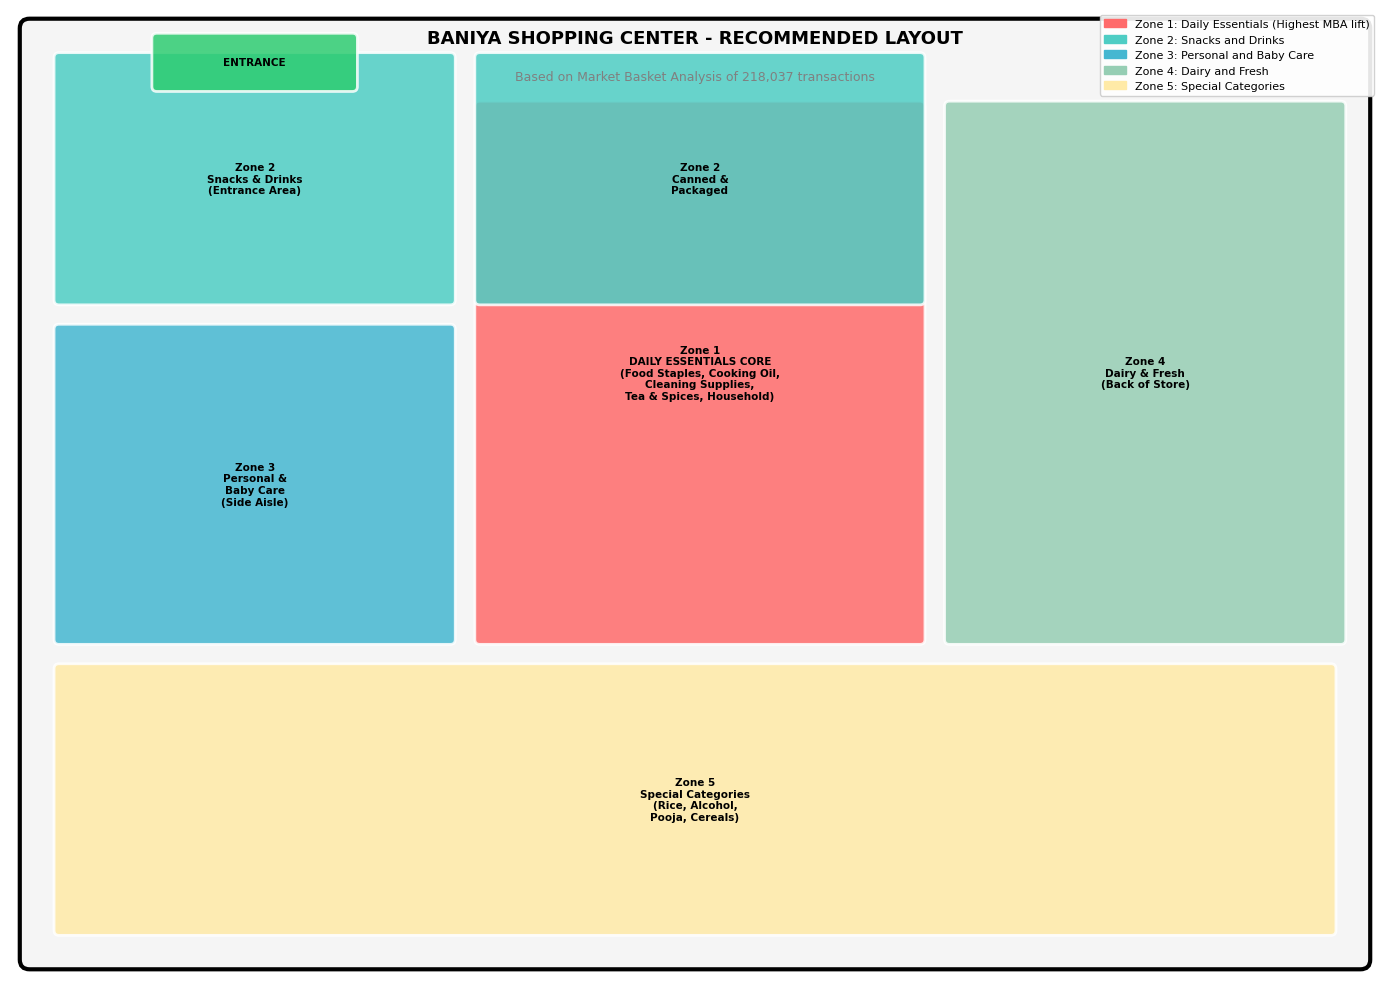

Store planogram saved!


In [4]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.set_facecolor('#F5F5F5')

store_outline = FancyBboxPatch((0.2, 0.2), 13.6, 9.6,
    boxstyle="round,pad=0.1", linewidth=3,
    edgecolor='black', facecolor='#F5F5F5')
ax.add_patch(store_outline)

zones_layout = [
    {'zone': 'Zone 2\nSnacks & Drinks\n(Entrance Area)', 
     'x': 0.5, 'y': 7.0, 'w': 4.0, 'h': 2.5, 'color': '#4ECDC4'},
    {'zone': 'ENTRANCE', 
     'x': 1.5, 'y': 9.2, 'w': 2.0, 'h': 0.5, 'color': '#2ECC71'},
    {'zone': 'Zone 1\nDAILY ESSENTIALS CORE\n(Food Staples, Cooking Oil,\nCleaning Supplies,\nTea & Spices, Household)', 
     'x': 4.8, 'y': 3.5, 'w': 4.5, 'h': 5.5, 'color': '#FF6B6B'},
    {'zone': 'Zone 3\nPersonal &\nBaby Care\n(Side Aisle)', 
     'x': 0.5, 'y': 3.5, 'w': 4.0, 'h': 3.2, 'color': '#45B7D1'},
    {'zone': 'Zone 4\nDairy & Fresh\n(Back of Store)', 
     'x': 9.6, 'y': 3.5, 'w': 4.0, 'h': 5.5, 'color': '#96CEB4'},
    {'zone': 'Zone 5\nSpecial Categories\n(Rice, Alcohol,\nPooja, Cereals)', 
     'x': 0.5, 'y': 0.5, 'w': 13.0, 'h': 2.7, 'color': '#FFEAA7'},
    {'zone': 'Zone 2\nCanned &\nPackaged', 
     'x': 4.8, 'y': 7.0, 'w': 4.5, 'h': 2.5, 'color': '#4ECDC4'},
]

for zone in zones_layout:
    rect = FancyBboxPatch(
        (zone['x'], zone['y']), zone['w'], zone['h'],
        boxstyle="round,pad=0.05",
        linewidth=2, edgecolor='white',
        facecolor=zone['color'], alpha=0.85
    )
    ax.add_patch(rect)
    ax.text(zone['x'] + zone['w']/2, zone['y'] + zone['h']/2,
            zone['zone'], ha='center', va='center',
            fontsize=7.5, fontweight='bold', wrap=True)

ax.text(7, 9.7, 'BANIYA SHOPPING CENTER - RECOMMENDED LAYOUT',
        ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(7, 9.3, 'Based on Market Basket Analysis of 218,037 transactions',
        ha='center', va='center', fontsize=9, color='gray')

legend_elements = [
    mpatches.Patch(color='#FF6B6B', label='Zone 1: Daily Essentials (Highest MBA lift)'),
    mpatches.Patch(color='#4ECDC4', label='Zone 2: Snacks and Drinks'),
    mpatches.Patch(color='#45B7D1', label='Zone 3: Personal and Baby Care'),
    mpatches.Patch(color='#96CEB4', label='Zone 4: Dairy and Fresh'),
    mpatches.Patch(color='#FFEAA7', label='Zone 5: Special Categories'),
]
ax.legend(handles=legend_elements, loc='upper right',
          fontsize=8, framealpha=0.9)

ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart12_store_planogram.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Store planogram saved!")

## Step 4: Projected Revenue Impact

### Why 3%, 5% and 8% uplift?

Retail industry research shows that optimising product placement typically increases average basket value by 2% to 8%. We use three scenarios. Conservative at 3% assumes minimal customer behaviour change. Moderate at 5% is the most realistic target based on the strength of our association rules. Optimistic at 8% assumes customers respond strongly to the new layout. These ranges are standard in retail analytics literature.

In [5]:
basket_values = df.groupby('invoice_no')['total_amount'].sum()
current_avg_basket = basket_values.mean()
current_daily_revenue = df['total_amount'].sum() / 307
current_daily_customers = df['invoice_no'].nunique() / 307

scenarios = {
    'Conservative (3% increase)': 0.03,
    'Moderate (5% increase)': 0.05,
    'Optimistic (8% increase)': 0.08
}

print("PROJECTED REVENUE IMPACT OF OPTIMIZED PLACEMENT")
print("=" * 65)
print(f"\nCURRENT BASELINE:")
print(f"  Average basket value:   Rs {current_avg_basket:,.2f}")
print(f"  Daily revenue:          Rs {current_daily_revenue:,.2f}")
print(f"  Daily customers:        {current_daily_customers:,.0f} trips")
print(f"\nPROJECTED IMPROVEMENTS:")
print("-" * 65)

for scenario, increase in scenarios.items():
    new_basket = current_avg_basket * (1 + increase)
    extra_per_basket = new_basket - current_avg_basket
    extra_daily = extra_per_basket * current_daily_customers
    extra_monthly = extra_daily * 30
    extra_annual = extra_daily * 365

    print(f"\n{scenario}")
    print(f"  New average basket:     Rs {new_basket:,.2f}")
    print(f"  Extra per basket:       Rs {extra_per_basket:,.2f}")
    print(f"  Extra revenue daily:    Rs {extra_daily:,.2f}")
    print(f"  Extra revenue monthly:  Rs {extra_monthly:,.2f}")
    print(f"  Extra revenue annually: Rs {extra_annual:,.2f}")

PROJECTED REVENUE IMPACT OF OPTIMIZED PLACEMENT

CURRENT BASELINE:
  Average basket value:   Rs 1,000.81
  Daily revenue:          Rs 710,796.28
  Daily customers:        710 trips

PROJECTED IMPROVEMENTS:
-----------------------------------------------------------------

Conservative (3% increase)
  New average basket:     Rs 1,030.84
  Extra per basket:       Rs 30.02
  Extra revenue daily:    Rs 21,323.89
  Extra revenue monthly:  Rs 639,716.65
  Extra revenue annually: Rs 7,783,219.23

Moderate (5% increase)
  New average basket:     Rs 1,050.85
  Extra per basket:       Rs 50.04
  Extra revenue daily:    Rs 35,539.81
  Extra revenue monthly:  Rs 1,066,194.41
  Extra revenue annually: Rs 12,972,032.05

Optimistic (8% increase)
  New average basket:     Rs 1,080.88
  Extra per basket:       Rs 80.07
  Extra revenue daily:    Rs 56,863.70
  Extra revenue monthly:  Rs 1,705,911.06
  Extra revenue annually: Rs 20,755,251.27


### Grounding the Projection in the Store's Own Data: 95% Confidence Interval

The Rs 1.30 crore annual figure in the moderate scenario above comes from applying an industry benchmark uplift of 5% to the store's average basket value. The benchmark percentage itself cannot be validated without a live trial in the store, but the baseline it is applied to can be strengthened with our own data. Basket values vary a lot from customer to customer, so instead of trusting a single point estimate of the mean basket value, we calculate a 95% confidence interval for the mean from the actual variance across all 218,037 baskets. Applying the same 5% uplift to the lower bound, the mean and the upper bound turns the single projection into a range grounded in the store's own data. This is still clearly a projection, not a measured result, but the range now reflects the real variability of this store's baskets rather than one unqualified number.

In [6]:
from scipy import stats

basket_values = df.groupby('invoice_no')['total_amount'].sum()
n_baskets = len(basket_values)
mean_basket = basket_values.mean()
std_basket = basket_values.std()
se_basket = std_basket / np.sqrt(n_baskets)

ci_low, ci_high = stats.t.interval(0.95, n_baskets - 1, loc=mean_basket, scale=se_basket)

print("BASKET VALUE VARIANCE AND 95% CONFIDENCE INTERVAL")
print("=" * 65)
print(f"Baskets analysed:                {n_baskets:,}")
print(f"Mean basket value:               Rs {mean_basket:,.2f}")
print(f"Standard deviation:              Rs {std_basket:,.2f}")
print(f"Standard error of the mean:      Rs {se_basket:,.2f}")
print(f"95% CI for mean basket value:    Rs {ci_low:,.2f} to Rs {ci_high:,.2f}")

UPLIFT = 0.05
daily_customers = n_baskets / 307

print()
print("PROJECTED ANNUAL UPLIFT AT 5% BASKET VALUE INCREASE")
print("-" * 65)
uplift_results = {}
for label, base in [('Lower bound of CI', ci_low),
                    ('Mean basket value', mean_basket),
                    ('Upper bound of CI', ci_high)]:
    extra_annual = base * UPLIFT * daily_customers * 365
    uplift_results[label] = extra_annual
    print(f"{label:<22} Rs {base:>9,.2f} basket  ->  Rs {extra_annual:>13,.2f} per year")

print()
print("PROJECTION (not a measured result):")
print(f"Assuming the moderate 5% uplift scenario, we are 95% confident the")
print(f"actual annual uplift from a 5% basket value increase would be between")
print(f"Rs {uplift_results['Lower bound of CI']:,.0f} and Rs {uplift_results['Upper bound of CI']:,.0f}.")
print(f"The 5% uplift assumption itself remains an industry benchmark and")
print(f"would need a live in-store trial to verify.")

BASKET VALUE VARIANCE AND 95% CONFIDENCE INTERVAL
Baskets analysed:                218,037
Mean basket value:               Rs 1,000.81
Standard deviation:              Rs 1,645.91
Standard error of the mean:      Rs 3.52
95% CI for mean basket value:    Rs 993.91 to Rs 1,007.72

PROJECTED ANNUAL UPLIFT AT 5% BASKET VALUE INCREASE
-----------------------------------------------------------------
Lower bound of CI      Rs    993.91 basket  ->  Rs 12,882,485.99 per year
Mean basket value      Rs  1,000.81 basket  ->  Rs 12,972,032.05 per year
Upper bound of CI      Rs  1,007.72 basket  ->  Rs 13,061,578.11 per year

PROJECTION (not a measured result):
Assuming the moderate 5% uplift scenario, we are 95% confident the
actual annual uplift from a 5% basket value increase would be between
Rs 12,882,486 and Rs 13,061,578.
The 5% uplift assumption itself remains an industry benchmark and
would need a live in-store trial to verify.


### Revenue Impact Visualization

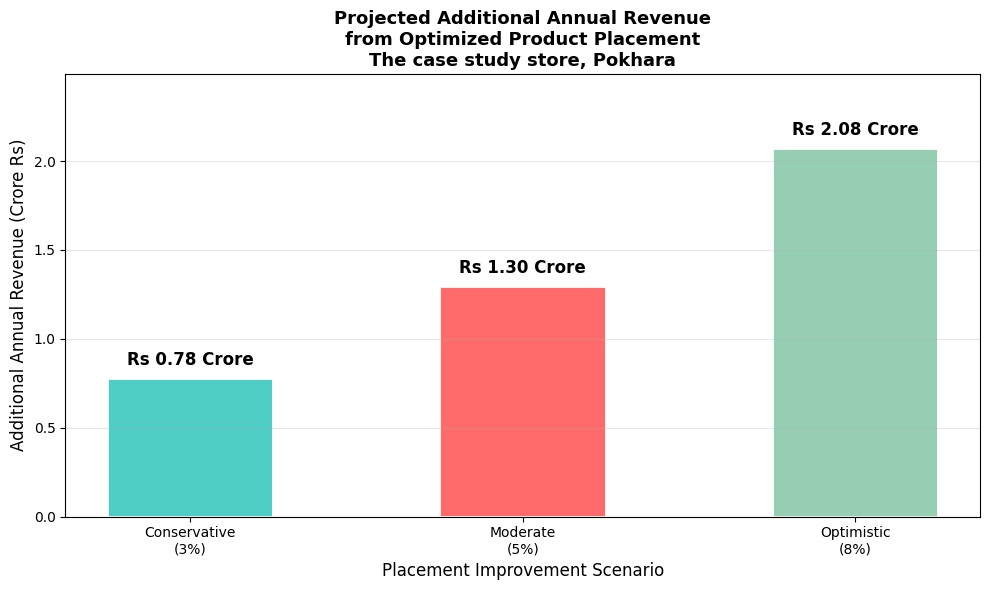

Revenue impact chart saved!


In [7]:
scenarios_labels = ['Conservative\n(3%)', 'Moderate\n(5%)', 'Optimistic\n(8%)']
extra_annual = [7783219.23, 12972032.05, 20755251.27]
extra_annual_crore = [x/10000000 for x in extra_annual]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(scenarios_labels, extra_annual_crore, 
              color=['#4ECDC4', '#FF6B6B', '#96CEB4'],
              width=0.5, edgecolor='white', linewidth=2)

for bar, val in zip(bars, extra_annual_crore):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'Rs {val:.2f} Crore', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_xlabel('Placement Improvement Scenario', fontsize=12)
ax.set_ylabel('Additional Annual Revenue (Crore Rs)', fontsize=12)
ax.set_title('Projected Additional Annual Revenue\nfrom Optimized Product Placement\nThe case study store, Pokhara',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(extra_annual_crore) * 1.2)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart13_revenue_impact.png'), dpi=150)
plt.show()
print("Revenue impact chart saved!")

## Step 5: Before vs After Store Layout Comparison

### Note on Before Layout

The before layout shown below is a hypothetical unoptimised layout used as a baseline for comparison. The actual current layout of the case study store was not available in digital format. The before layout represents a typical unplanned grocery store arrangement where products are placed without data driven strategy.

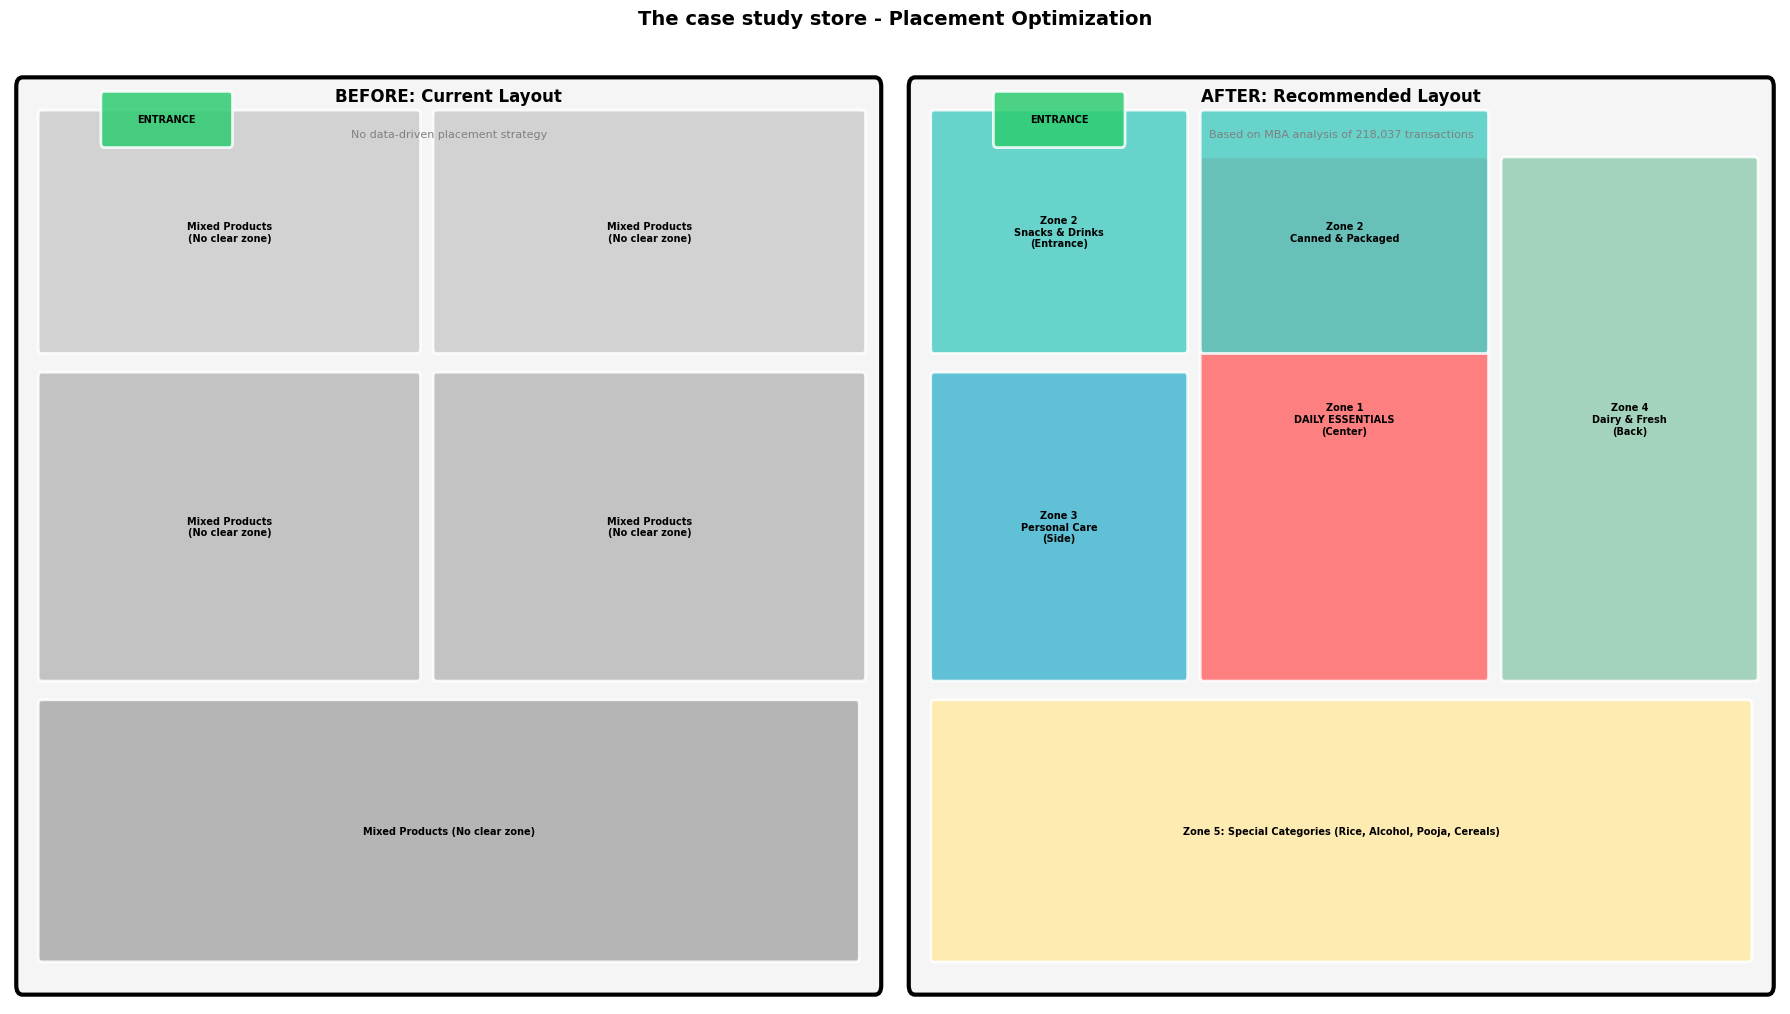

Before vs After layout saved!


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

def draw_layout(ax, title, zones, subtitle):
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.set_facecolor('#F5F5F5')
    store = FancyBboxPatch((0.2, 0.2), 13.6, 9.6,
        boxstyle="round,pad=0.1", linewidth=3,
        edgecolor='black', facecolor='#F5F5F5')
    ax.add_patch(store)
    for zone in zones:
        rect = FancyBboxPatch(
            (zone['x'], zone['y']), zone['w'], zone['h'],
            boxstyle="round,pad=0.05",
            linewidth=2, edgecolor='white',
            facecolor=zone['color'], alpha=0.85)
        ax.add_patch(rect)
        ax.text(zone['x'] + zone['w']/2, zone['y'] + zone['h']/2,
                zone['label'], ha='center', va='center',
                fontsize=7, fontweight='bold')
    ax.text(7, 9.7, title, ha='center', va='center',
            fontsize=12, fontweight='bold')
    ax.text(7, 9.3, subtitle, ha='center', va='center',
            fontsize=8, color='gray')
    ax.axis('off')

before_zones = [
    {'x': 0.5, 'y': 7.0, 'w': 6.0, 'h': 2.5, 'color': '#CCCCCC',
     'label': 'Mixed Products\n(No clear zone)'},
    {'x': 6.8, 'y': 7.0, 'w': 6.8, 'h': 2.5, 'color': '#CCCCCC',
     'label': 'Mixed Products\n(No clear zone)'},
    {'x': 0.5, 'y': 3.5, 'w': 6.0, 'h': 3.2, 'color': '#BBBBBB',
     'label': 'Mixed Products\n(No clear zone)'},
    {'x': 6.8, 'y': 3.5, 'w': 6.8, 'h': 3.2, 'color': '#BBBBBB',
     'label': 'Mixed Products\n(No clear zone)'},
    {'x': 0.5, 'y': 0.5, 'w': 13.0, 'h': 2.7, 'color': '#AAAAAA',
     'label': 'Mixed Products (No clear zone)'},
    {'x': 1.5, 'y': 9.2, 'w': 2.0, 'h': 0.5, 'color': '#2ECC71',
     'label': 'ENTRANCE'},
]

after_zones = [
    {'x': 0.5, 'y': 7.0, 'w': 4.0, 'h': 2.5, 'color': '#4ECDC4',
     'label': 'Zone 2\nSnacks & Drinks\n(Entrance)'},
    {'x': 1.5, 'y': 9.2, 'w': 2.0, 'h': 0.5, 'color': '#2ECC71',
     'label': 'ENTRANCE'},
    {'x': 4.8, 'y': 3.5, 'w': 4.5, 'h': 5.5, 'color': '#FF6B6B',
     'label': 'Zone 1\nDAILY ESSENTIALS\n(Center)'},
    {'x': 0.5, 'y': 3.5, 'w': 4.0, 'h': 3.2, 'color': '#45B7D1',
     'label': 'Zone 3\nPersonal Care\n(Side)'},
    {'x': 9.6, 'y': 3.5, 'w': 4.0, 'h': 5.5, 'color': '#96CEB4',
     'label': 'Zone 4\nDairy & Fresh\n(Back)'},
    {'x': 0.5, 'y': 0.5, 'w': 13.0, 'h': 2.7, 'color': '#FFEAA7',
     'label': 'Zone 5: Special Categories (Rice, Alcohol, Pooja, Cereals)'},
    {'x': 4.8, 'y': 7.0, 'w': 4.5, 'h': 2.5, 'color': '#4ECDC4',
     'label': 'Zone 2\nCanned & Packaged'},
]

draw_layout(ax1, 'BEFORE: Current Layout',
            before_zones, 'No data-driven placement strategy')
draw_layout(ax2, 'AFTER: Recommended Layout',
            after_zones, 'Based on MBA analysis of 218,037 transactions')

plt.suptitle('The case study store - Placement Optimization',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart14_before_after_layout.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Before vs After layout saved!")

## Step 6: Monthly Sales Trend and Stock Recommendation

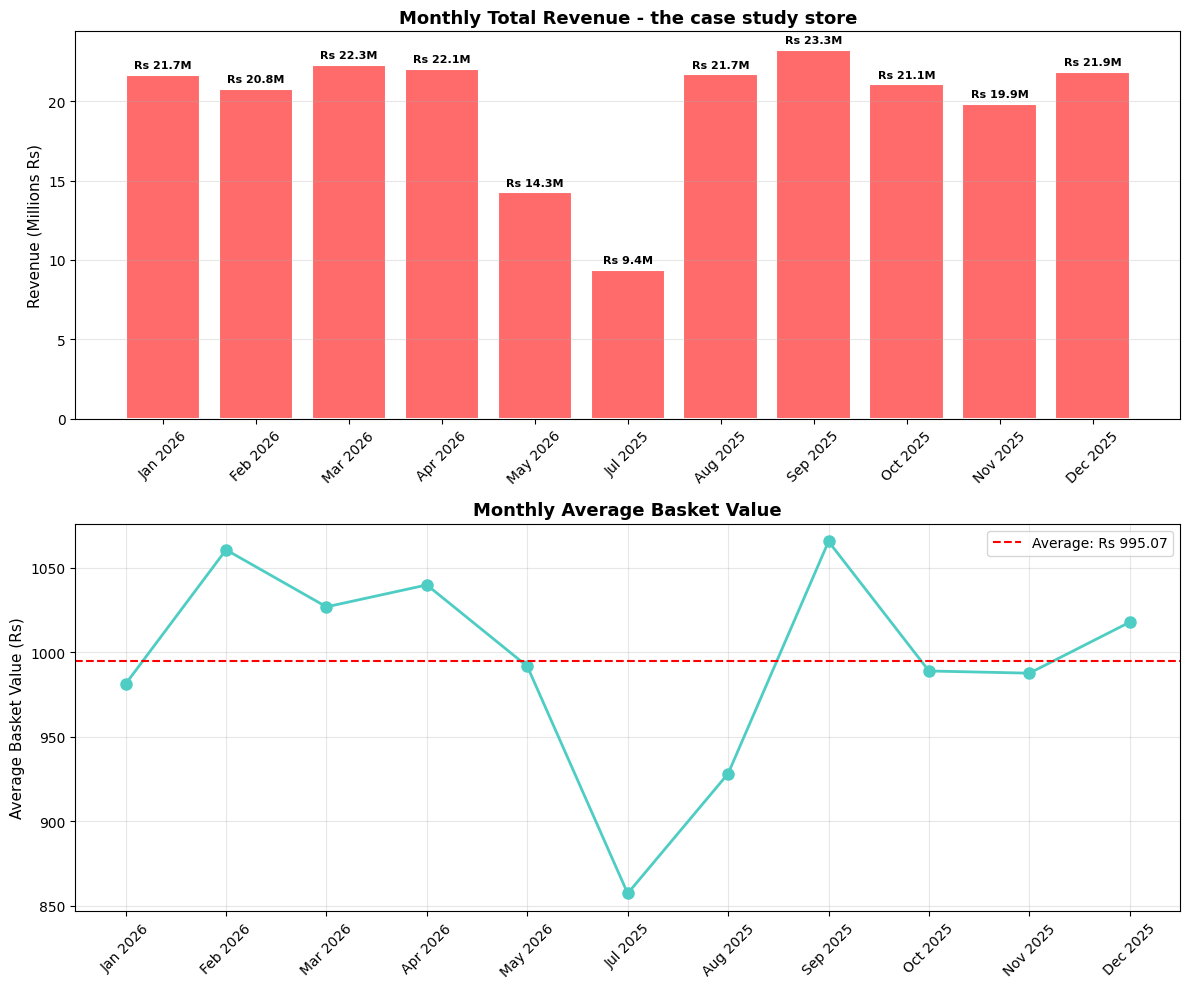

Monthly trends chart saved!

Monthly Summary:
month_name  total_amount  baskets  avg_basket
  Jan 2026  2.169118e+07    22106  981.234914
  Feb 2026  2.078996e+07    19600 1060.712235
  Mar 2026  2.231156e+07    21727 1026.904565
  Apr 2026  2.206134e+07    21215 1039.893240
  May 2026  1.426466e+07    14384  991.703336
  Jul 2025  9.362753e+06    10923  857.159495
  Aug 2025  2.169897e+07    23379  928.139408
  Sep 2025  2.325475e+07    21822 1065.656373
  Oct 2025  2.107200e+07    21308  988.924160
  Nov 2025  1.985216e+07    20101  987.620465
  Dec 2025  2.185513e+07    21472 1017.843424


In [9]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b %Y')

monthly_revenue = df.groupby(['month', 'month_name'])['total_amount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('month')

monthly_baskets = df.groupby('month')['invoice_no'].nunique().reset_index()
monthly_baskets.columns = ['month', 'baskets']
monthly_revenue = monthly_revenue.merge(monthly_baskets, on='month')
monthly_revenue['avg_basket'] = monthly_revenue['total_amount'] / monthly_revenue['baskets']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].bar(monthly_revenue['month_name'], 
            monthly_revenue['total_amount']/1000000,
            color='#FF6B6B', edgecolor='white', linewidth=1.5)
axes[0].set_title('Monthly Total Revenue - the case study store', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (Millions Rs)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(monthly_revenue.iterrows()):
    axes[0].text(i, row['total_amount']/1000000 + 0.3,
                f"Rs {row['total_amount']/1000000:.1f}M",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[1].plot(monthly_revenue['month_name'], 
             monthly_revenue['avg_basket'],
             'bo-', markersize=8, linewidth=2, color='#4ECDC4')
axes[1].axhline(y=monthly_revenue['avg_basket'].mean(), 
                color='red', linestyle='--', linewidth=1.5,
                label=f"Average: Rs {monthly_revenue['avg_basket'].mean():.2f}")
axes[1].set_title('Monthly Average Basket Value', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Basket Value (Rs)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart15_monthly_trends.png'), dpi=150)
plt.show()
print("Monthly trends chart saved!")
print("\nMonthly Summary:")
print(monthly_revenue[['month_name', 'total_amount', 'baskets', 'avg_basket']].to_string(index=False))

### Note on May 2026 Data

May 2026 shows lower sales than other months because the data only covers part of May, not the full month. This makes May look like a slow month when it is actually just incomplete data. Keep this in mind when reading the monthly trend chart.

## Step 7: Stock Recommendation by Month

In [10]:
monthly_category = df.groupby(['month', 'month_name', 'category'])['total_amount'].sum().reset_index()
monthly_category = monthly_category.sort_values('month')

month_order = monthly_category.sort_values('month')[['month', 'month_name']].drop_duplicates()

season_map = {
    7: 'Monsoon', 8: 'Monsoon', 9: 'Festival Season',
    10: 'Festival Season', 11: 'Winter', 12: 'Winter',
    1: 'Winter', 2: 'Spring', 3: 'Spring',
    4: 'Spring', 5: 'Pre-Summer'
}

print("STOCK RECOMMENDATION BY MONTH")
print("=" * 70)
print("Top 5 categories to stock up each month:\n")

for _, month_row in month_order.iterrows():
    month_num = month_row['month']
    month_name = month_row['month_name']
    season = season_map.get(month_num, 'Regular')
    
    top5 = monthly_category[
        monthly_category['month'] == month_num
    ].nlargest(5, 'total_amount')
    
    print(f"{month_name} ({season}):")
    for _, row in top5.iterrows():
        print(f"  - {row['category']:<35} Rs {row['total_amount']:>10,.0f}")
    print()

STOCK RECOMMENDATION BY MONTH
Top 5 categories to stock up each month:

Jan 2026 (Winter):
  - FOOD STAPLES                        Rs  3,332,490
  - COOKING OIL                         Rs  2,856,129
  - RICE                                Rs  2,426,268
  - CANNED AND PACKAGED FOODS           Rs  1,823,078
  - ALCOHOLIC BEVERAGES                 Rs  1,466,960

Feb 2026 (Spring):
  - FOOD STAPLES                        Rs  3,025,078
  - COOKING OIL                         Rs  2,793,787
  - RICE                                Rs  2,526,376
  - CANNED AND PACKAGED FOODS           Rs  1,614,494
  - ALCOHOLIC BEVERAGES                 Rs  1,584,169

Mar 2026 (Spring):
  - COOKING OIL                         Rs  3,306,503
  - FOOD STAPLES                        Rs  3,283,380
  - RICE                                Rs  2,650,975
  - CANNED AND PACKAGED FOODS           Rs  1,800,716
  - CIGARETTE AND TOBACCO               Rs  1,500,932

Apr 2026 (Spring):
  - FOOD STAPLES                       

Nov 2025 (Winter):
  - FOOD STAPLES                        Rs  3,051,980
  - COOKING OIL                         Rs  2,431,872
  - RICE                                Rs  2,352,435
  - CANNED AND PACKAGED FOODS           Rs  1,633,057
  - CIGARETTE AND TOBACCO               Rs  1,304,658

Dec 2025 (Winter):
  - FOOD STAPLES                        Rs  3,333,849
  - COOKING OIL                         Rs  2,661,157
  - RICE                                Rs  2,334,559
  - CANNED AND PACKAGED FOODS           Rs  1,903,889
  - CIGARETTE AND TOBACCO               Rs  1,487,854



## Placement Simulation Complete

### Current Baseline
- Average basket value: Rs 1,000.81
- Daily revenue: Rs 710,796
- Daily customer trips: 710

### Recommended Layout
5 zones designed from MBA association rules and co-occurrence clustering:
- Zone 1 Center: FOOD STAPLES, COOKING OIL, CLEANING SUPPLIES, TEA AND SPICES, HOUSEHOLD ITEMS
- Zone 2 Entrance: NOODLES, SOFT DRINKS, BISCUITS, CONFECTIONERY, NAMKEEN, CANNED FOODS
- Zone 3 Side: PERSONAL CARE, BABY CARE, STATIONERY
- Zone 4 Back: DAIRY, FROZEN, FRUITS, BAKERY
- Zone 5 Perimeter: RICE, ALCOHOL, CIGARETTES, POOJA, CEREALS, ELECTRICAL, PARTY

### Projected Revenue Impact
- Conservative 3%: Rs 0.78 Crore extra per year
- Moderate 5%: Rs 1.30 Crore extra per year
- Optimistic 8%: Rs 2.08 Crore extra per year

### Seasonal Insight
September 2025 was the highest revenue month at Rs 23.3 million due to Dashain festival. Stock up ALCOHOLIC BEVERAGES and CONFECTIONERY in September and October. FOOD STAPLES, COOKING OIL and RICE are top 3 every single month without exception.

### Note
The 5% moderate scenario is our primary recommendation. It is realistic based on the strength of our association rules where 48 rules have lift above 5.0 and our maximum lift is 6.81.

### Next Step: 08_evaluation.ipynb

# === ADDED === RQ2 / Objective 4: Cross-Sell Before vs After (data-driven)

The 3% / 5% / 8% figures above are **projections** based on retail benchmarks. To answer **RQ2 / Objective 4** with an actual data-driven result, we measure how much **cross-selling potential** each layout captures, straight from the association rules.

**Method.** A strong cross-sell rule is one with **lift &ge; 3** (the threshold used throughout this project for a strong relationship). A rule is *captured* by a layout when every category in the rule sits inside the **same group** of that layout, i.e. the products are placed next to each other so the cross-sell can actually happen on the shelf. We compare two layouts:

- **Current (before):** the frequency-based K-Means clusters from notebook 06 (k=5) &mdash; the unoptimised grouping driven by popularity, not co-purchase.
- **Optimised (after):** the 5 designed placement zones defined above.

We then count how many strong rules, and how much of the total strong-rule support, each layout co-locates. The delta is the data-driven before/after answer. The rupee value stays a separate projection.

In [11]:
# === ADDED === Compute cross-sell capture for current vs optimised layout
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Build the category basket matrix and mine association rules (same params as notebook 05)
xsell_basket = (
    df.groupby('invoice_no')['category']
      .apply(lambda s: pd.Series(1, index=s.unique()))
      .unstack(fill_value=0)
      .astype(bool)
)
xsell_frequent = apriori(xsell_basket, min_support=0.01, use_colnames=True)
xsell_rules = association_rules(xsell_frequent, metric='lift', min_threshold=1.0)

# 2. Keep only strong cross-sell rules (lift >= 3)
LIFT_FLOOR = 3.0
strong = xsell_rules[xsell_rules['lift'] >= LIFT_FLOOR].copy()
strong['cats'] = strong.apply(lambda r: set(r['antecedents']) | set(r['consequents']), axis=1)

# 3. CURRENT (before) layout = frequency K-Means clusters, k=5 (notebook 06 baseline)
cat_matrix = xsell_basket.astype(int).T
freq_scaled = StandardScaler().fit_transform(cat_matrix)
freq_labels = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(freq_scaled)
current_groups = [set(xsell_basket.columns[freq_labels == c]) for c in range(5)]

# 4. OPTIMISED (after) layout = the 5 designed zones
optimised_groups = [set(z['categories']) for z in placement_zones.values()]

# 5. A rule is captured when all its categories sit in one group
def capture(groups):
    mask = strong['cats'].apply(lambda c: any(c <= g for g in groups))
    return int(mask.sum()), float(strong.loc[mask, 'support'].sum())

cur_rules, cur_support = capture(current_groups)
opt_rules, opt_support = capture(optimised_groups)
total_support = strong['support'].sum()

print("CROSS-SELL CAPTURE: BEFORE vs AFTER")
print("=" * 60)
print(f"Strong cross-sell rules (lift >= {LIFT_FLOOR:.0f}): {len(strong)}")
print(f"\nCURRENT layout (frequency clusters):")
print(f"  Rules co-located:   {cur_rules}")
print(f"  Strong support captured: {cur_support/total_support*100:.1f}%")
print(f"\nOPTIMISED layout (5 designed zones):")
print(f"  Rules co-located:   {opt_rules}")
print(f"  Strong support captured: {opt_support/total_support*100:.1f}%")
print(f"\nDATA-DRIVEN RESULT (RQ2):")
print(f"  +{opt_rules - cur_rules} more strong rules co-located ({opt_rules/max(cur_rules,1):.1f}x)")
print(f"  Cross-sell capture rises from {cur_support/total_support*100:.1f}% to {opt_support/total_support*100:.1f}% of strong-rule support")
print(f"\nNote: this is measured from the rules. The Rs uplift above remains a projection.")

CROSS-SELL CAPTURE: BEFORE vs AFTER
Strong cross-sell rules (lift >= 3): 360

CURRENT layout (frequency clusters):
  Rules co-located:   28
  Strong support captured: 8.2%

OPTIMISED layout (5 designed zones):
  Rules co-located:   56
  Strong support captured: 16.3%

DATA-DRIVEN RESULT (RQ2):
  +28 more strong rules co-located (2.0x)
  Cross-sell capture rises from 8.2% to 16.3% of strong-rule support

Note: this is measured from the rules. The Rs uplift above remains a projection.


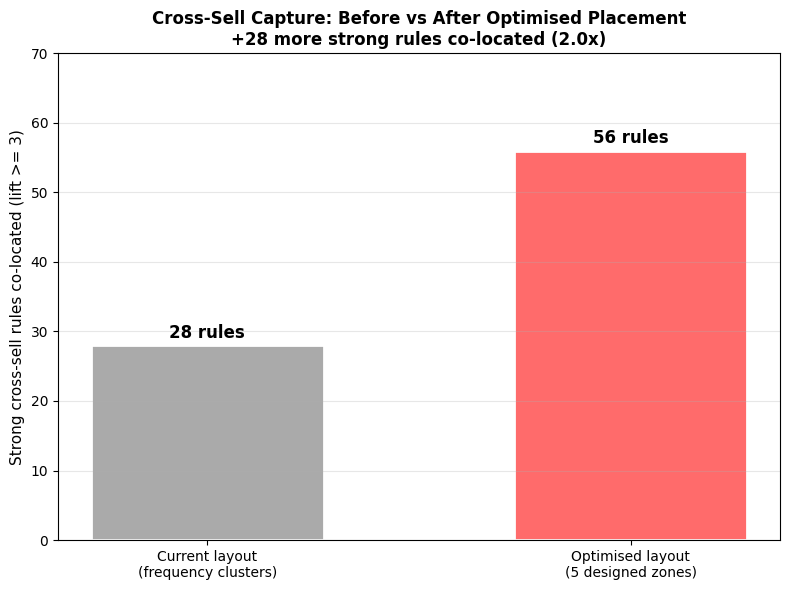

Cross-sell before/after chart saved!


In [12]:
# === ADDED === Visualise cross-sell capture before vs after
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['Current layout\n(frequency clusters)', 'Optimised layout\n(5 designed zones)']
values = [cur_rules, opt_rules]
bars = ax.bar(labels, values, color=['#AAAAAA', '#FF6B6B'],
              width=0.55, edgecolor='white', linewidth=2)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val} rules', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Strong cross-sell rules co-located (lift >= 3)', fontsize=11)
ax.set_title('Cross-Sell Capture: Before vs After Optimised Placement\n'
             f'+{opt_rules - cur_rules} more strong rules co-located ({opt_rules/max(cur_rules,1):.1f}x)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart22_crosssell_before_after.png'), dpi=150)
plt.show()
print("Cross-sell before/after chart saved!")